In [55]:
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
import os
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from lifelines import CoxPHFitter
warnings.filterwarnings('ignore')

In [64]:
#Load data
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')
meta = pd.read_csv('Data/metaData.csv')

#Convert to pd.Dataframe
train = pd.DataFrame(train)
test = pd.DataFrame(test)
train.shape

(221, 37)

In [57]:
#Training data
X_train = train.drop(columns=['event', 'event_id', 'time_to_hit_hours'])
y_train = train[['time_to_hit_hours', 'event']]
y_train['event'] = y_train['event'].astype(int)
y_train_surv = Surv.from_arrays(event=y_train["event"].astype(bool), 
                           time=y_train["time_to_hit_hours"])
event_val = y_train['event'].copy()
#Testing data
X_test = test.drop(columns=['event_id'])
event_id = test['event_id']

In [58]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
model = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=1000)
model.fit(X_train, y_train_surv)

,alpha,0.1
,ties,'breslow'
,n_iter,1000
,tol,1e-09
,verbose,0


In [60]:
risk_scores = model.predict(X_test)

In [61]:
surv_funcs = model.predict_survival_function(X_test)
p12 = [1 - sf(min(12, sf.x[-1])) for sf in surv_funcs]
p24 = [1 - sf(min(24, sf.x[-1])) for sf in surv_funcs]
p48 = [1 - sf(min(48, sf.x[-1])) for sf in surv_funcs]
p72 = [1 - sf(min(72, sf.x[-1])) for sf in surv_funcs]

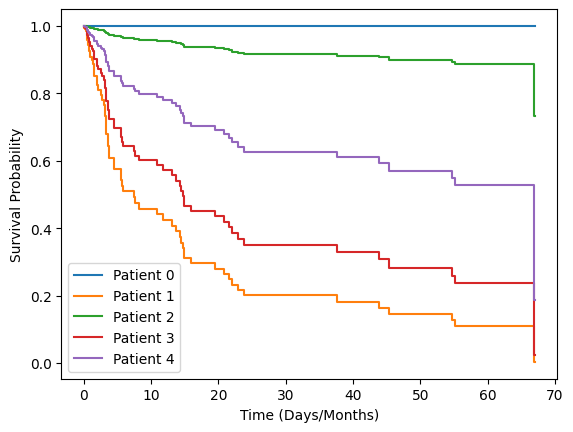

In [62]:
for i, surv_fn in enumerate(surv_funcs[:5]):
    plt.step(surv_fn.x, surv_fn.y, where="post", label=f"Patient {i}")

plt.ylabel("Survival Probability")
plt.xlabel("Time (Days/Months)")
plt.legend()
plt.show()

In [63]:
submission = {
    'event_id' : event_id,
    'prob_12h' : p12,
    'prob_24h' : p24,
    'prob_48h' : p48,
    'prob_72h' : p72
}
submission = pd.DataFrame(submission)
submission.to_csv('result.csv', index=False)